In [19]:
import sys
import numpy as np
import pandas as pd

def get_preds(fname):
    preds = []
    with open(fname, 'r') as f:
        for line in f:
            v=line.rstrip().split()
            #preds.append([v[0],float(v[2]),int(v[3])])
            preds.append([v[0],float(v[1]),int(v[2])])

    return preds



def get_cm(preds, th=0.001):
    cm = np.zeros((2, 2))
    n = len(preds)
    for k in range(n):
        j = 0
        i = preds[k][2]
        if preds[k][1] <= th:
            j=1
        cm[i][j] += 1
    return cm

def get_accuracy(cm):
    return (cm[0][0]+cm[1][1])/(cm.sum())

def get_mcc(cm):
    tp =cm[1,1]
    tn =cm[0,0]
    fp =cm[0,1]
    fn =cm[1,0]
    d = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc = (tp*tn-fp*fn)/np.sqrt(d) 
    return mcc


In [29]:
# generate thresholds (use numpy.arange for float step; avoid shadowing builtin 'eval')
thresholds = [10 ** -i for i in np.arange(2, 12, 0.3)]
results = {}
for th in thresholds:
    fname = "./New_analysis/kunitz_set_tot.txt"
    preds = get_preds(fname)
    cm = get_cm(preds, th)
    q2 = get_accuracy(cm)
    mcc = get_mcc(cm)

    results[th] = {'FP': cm[0][1], 'FN': cm[1][0], 'TP': cm[1][1], 'TN': cm[0][0], 'Accuracy': q2, 'MCC': mcc}

df = pd.DataFrame.from_dict(results, orient='index')
print(df)



                FP    FN     TP        TN  Accuracy       MCC
1.000000e-02  17.0   1.0  391.0  574213.0  0.999969  0.977680
5.011872e-03  11.0   2.0  390.0  574219.0  0.999977  0.983659
2.511886e-03   8.0   2.0  390.0  574222.0  0.999983  0.987362
1.258925e-03   6.0   2.0  390.0  574224.0  0.999986  0.989854
6.309573e-04   5.0   3.0  389.0  574225.0  0.999986  0.989818
3.162278e-04   4.0   3.0  389.0  574226.0  0.999988  0.991078
1.584893e-04   4.0   3.0  389.0  574226.0  0.999988  0.991078
7.943282e-05   3.0   4.0  388.0  574227.0  0.999988  0.991055
3.981072e-05   3.0   4.0  388.0  574227.0  0.999988  0.991055
1.995262e-05   3.0   4.0  388.0  574227.0  0.999988  0.991055
1.000000e-05   1.0   5.0  387.0  574229.0  0.999990  0.992316
5.011872e-06   1.0   5.0  387.0  574229.0  0.999990  0.992316
2.511886e-06   0.0   5.0  387.0  574230.0  0.999991  0.993598
1.258925e-06   0.0   5.0  387.0  574230.0  0.999991  0.993598
6.309573e-07   0.0   5.0  387.0  574230.0  0.999991  0.993598
3.162278

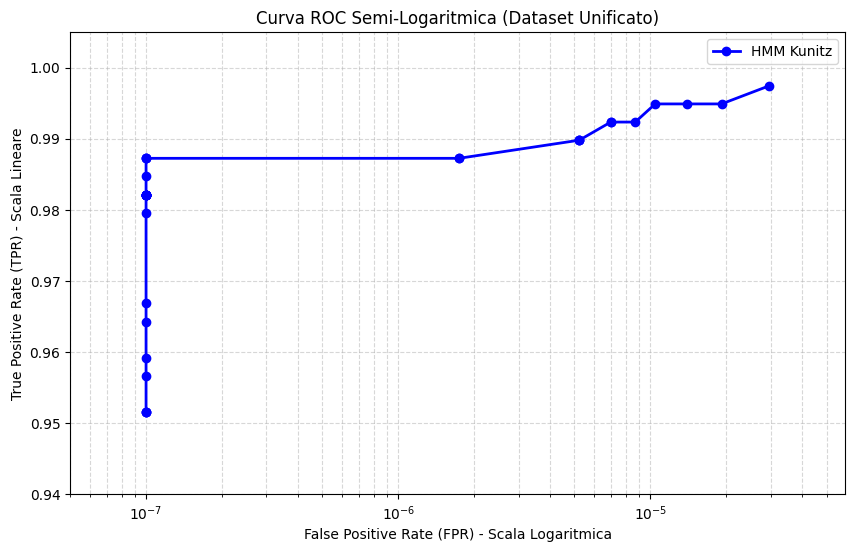

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Presupponendo che i tuoi dati siano già caricati nel dataframe 'df'

# 1. Calcolo metriche derivate
df['TPR'] = df['TP'] / (df['TP'] + df['FN'])
df['FPR'] = df['FP'] / (df['FP'] + df['TN'])

# 2. Gestione dello zero per la scala logaritmica (Epsilon)
# Il più piccolo FPR non nullo che hai è circa 1.7e-6 (per la soglia 1e-05)
# Fissiamo epsilon a 1e-7 per rappresentare lo "0" dei Falsi Positivi
epsilon = 1e-7 
df['FPR_log'] = df['FPR'].replace(0, epsilon)

# 3. Creazione del grafico
plt.figure(figsize=(10, 6))
plt.plot(df['FPR_log'], df['TPR'], marker='o', color='blue', linewidth=2, label='HMM Kunitz')

# 4. Impostazione assi e scale
plt.xscale('log')
plt.xlim([epsilon / 2, df['FPR'].max() * 2])
plt.ylim([0.94, 1.005]) # Zoom mirato sulla variazione del TPR

# 5. Estetica e labels
plt.title('Curva ROC Semi-Logaritmica (Dataset Unificato)')
plt.xlabel('False Positive Rate (FPR) - Scala Logaritmica')
plt.ylabel('True Positive Rate (TPR) - Scala Lineare')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.show()